# Part 2 – Inter-Array Cabling Losses [8 pts]
OE44170 Offshore Renewable Technologies – Assignment: Electrical Aspects

Given: 20 MW WTGs at $\cos\varphi = 0.95$, 66 kV inter-array cables (IAC), no wake losses.

| Cable | Type [mm²] | Ampacity [A] | R [Ω/km] |
|---|---|---|---|
| 1 | 400 | 424 | 0.101 |
| 2 | 630 | 584 | 0.063 |
| 3 | 800 | 750 | 0.037 |

This notebook
1. computes the rated current per WTG and the maximum number of WTGs per cable type,
2. reproduces the `IAC` tab of the template and **fills in all yellow cells** (written as Excel formulas to
   `output/ORT_Assignment_Wind_Electrical_completed.xlsx`),
3. computes the annual IAC losses at 66 kV and at 132 kV.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import openpyxl
from openpyxl.styles import PatternFill

XLSX = Path("data/ORT_Assignment_Wind_Electrical.xlsx")
OUT_XLSX = Path("output/ORT_Assignment_Wind_Electrical_completed.xlsx"); OUT_XLSX.parent.mkdir(exist_ok=True)
FIG = Path("report/figures/electrical"); FIG.mkdir(parents=True, exist_ok=True)
plt.rcParams.update({"figure.dpi": 110, "savefig.dpi": 200, "font.size": 10, "axes.grid": True, "grid.alpha": 0.3})

P_WTG = 20.0      # MW
COS_PHI = 0.95
U_IAC = 66.0      # kV (phase-to-phase)
cables = pd.DataFrame({"type_mm2": [400, 630, 800], "ampacity_A": [424, 584, 750],
                       "R_ohm_per_km": [0.101, 0.063, 0.037]}, index=["Cable 1", "Cable 2", "Cable 3"])

## Q1 – Rated current per wind turbine
$$S = \frac{P}{\cos\varphi}, \qquad I = \frac{S}{\sqrt{3}\,U_{ph-ph}}$$

In [2]:
S_WTG = P_WTG / COS_PHI                              # MVA
I_WTG = S_WTG * 1e6 / (np.sqrt(3) * U_IAC * 1e3)     # A
print(f"S_WTG = {P_WTG} / {COS_PHI} = {S_WTG:.2f} MVA")
print(f"I_WTG = {S_WTG:.2f} MVA / (sqrt(3) x {U_IAC:.0f} kV) = {I_WTG:.1f} A")
S_TEMPLATE = 21.1                                     # value given in the template (rounded)
print(f"(with the rounded template value 21.1 MVA: {S_TEMPLATE*1e3/(np.sqrt(3)*U_IAC):.1f} A)")

S_WTG = 20.0 / 0.95 = 21.05 MVA
I_WTG = 21.05 MVA / (sqrt(3) x 66 kV) = 184.2 A
(with the rounded template value 21.1 MVA: 184.6 A)


## Q2 – Maximum number of WTGs per cable type
$n_{max} = \lfloor \text{ampacity} / I_{WTG} \rfloor$

In [3]:
cables["I_ampacity / I_WTG"] = cables["ampacity_A"] / I_WTG
cables["n_max WTGs"] = np.floor(cables["I_ampacity / I_WTG"]).astype(int)
cables["current at n_max [A]"] = cables["n_max WTGs"] * I_WTG
cables["loading at n_max [%]"] = 100 * cables["current at n_max [A]"] / cables["ampacity_A"]
cables.round(2)

,type_mm2,ampacity_A,R_ohm_per_km,I_ampacity / I_WTG,n_max WTGs,current at n_max [A],loading at n_max [%]
Cable 1,400,424,0.10,2.30,2,368.33,86.87
Cable 2,630,584,0.06,3.17,3,552.49,94.60
Cable 3,800,750,0.04,4.07,4,736.65,98.22


## Q3 – Complete the `IAC` tab (string of 4 WTGs)
String sections (from the WTG at the end of the string towards the substation):

| Section | after WTG 1 | after WTG 2 | after WTG 3 | after WTG 4 |
|---|---|---|---|---|
| # WTGs carried | 1 | 2 | 3 | 4 |
| Length [km] | 2.5 | 2.5 | 2.0 | 1.5 |

The **cheapest cable that does not exceed its ampacity** is selected for each section (smallest
cross-section = cheapest). The losses per wind-speed bin follow the template formula
$$P_{loss} = 3\,\Big(\tfrac{S(v)}{S_{nom}}\, I_{nom,section}\Big)^2 R\,L ,$$
i.e. the section current scales with the actual apparent power $S(v) = P(v)/\cos\varphi$ of the WTGs.

In [4]:
raw = pd.read_excel(XLSX, sheet_name="WTG Yield Wake", header=None)
wind = raw.iloc[13:42, [7, 3, 8]].astype(float).fillna(0.0).reset_index(drop=True)
wind.columns = ["v", "P_MW", "time_pct"]
hours = wind["time_pct"] / 100 * 8760
hours.iloc[0] = 57          # template hard-codes 57 h for the 0.5 m/s bin
hours.iloc[-1] = 1          # template hard-codes 1 h for the 28.5 m/s bin
wind["hours"] = hours
wind["S_MVA"] = wind["P_MW"] / COS_PHI

S_nom = S_TEMPLATE          # MVA, template row 8
sections = pd.DataFrame({"n_WTG": [1, 2, 3, 4], "length_km": [2.5, 2.5, 2.0, 1.5]},
                        index=["WTG 1", "WTG 2", "WTG 3", "WTG 4"])
sections["I_nom [A]"] = sections["n_WTG"] * S_nom * 1e3 / (np.sqrt(3) * U_IAC)
def cheapest(I):
    ok = cables[cables["ampacity_A"] >= I]
    return int(ok.index[0].split()[-1])
sections["cable"] = sections["I_nom [A]"].apply(cheapest)
sections["R [ohm/km]"] = sections["cable"].map(lambda c: cables.iloc[c-1]["R_ohm_per_km"])
sections["loading [%]"] = 100 * sections["I_nom [A]"] / sections["cable"].map(lambda c: cables.iloc[c-1]["ampacity_A"])
sections.round(2)

/opt/anaconda3/lib/python3.13/site-packages/openpyxl/worksheet/_read_only.py:85: UserWarning: Unknown extension is not supported and will be removed
  for idx, row in parser.parse():


,n_WTG,length_km,I_nom [A],cable,R [ohm/km],loading [%]
WTG 1,1,2.5,184.58,1,0.10,43.53
WTG 2,2,2.5,369.15,1,0.10,87.06
WTG 3,3,2.0,553.73,2,0.06,94.82
WTG 4,4,1.5,738.31,3,0.04,98.44


In [5]:
def string_losses(U_kV, sec):
    I_nom = sec["n_WTG"].values * S_nom * 1e3 / (np.sqrt(3) * U_kV)
    R, L = sec["R [ohm/km]"].values, sec["length_km"].values
    ratio = (wind["S_MVA"].values / S_nom)[:, None]
    p_loss_kW = 3 * (ratio * I_nom[None, :]) ** 2 * R * L / 1000          # kW, per section
    table = pd.DataFrame(p_loss_kW, columns=[f"P_loss {c} [kW]" for c in sec.index])
    table.insert(0, "v [m/s]", wind["v"]); table.insert(1, "P [MW]", wind["P_MW"]); table.insert(2, "S [MVA]", wind["S_MVA"])
    table["P_loss total [kW]"] = p_loss_kW.sum(1)
    table["hours"] = wind["hours"]
    table["Loss [MWh/yr]"] = table["P_loss total [kW]"] * table["hours"] / 1000
    return table

iac66 = string_losses(66, sections)
loss66 = iac66["Loss [MWh/yr]"].sum()
yield_string = sections["n_WTG"].max() * (wind["P_MW"] * wind["hours"]).sum()   # 4 WTGs, MWh/yr
print(f"Total hours in table: {wind['hours'].sum():.0f} h")
print(f"IAC string losses (66 kV): {loss66:,.1f} MWh/yr")
print(f"WTG energy yield, 4 WTGs : {yield_string:,.0f} MWh/yr")
print(f"Losses                   : {100*loss66/yield_string:.3f} % of WTG yield")
print(f"Loss at full power        : {iac66['P_loss total [kW]'].max():.1f} kW = "
      f"{100*iac66['P_loss total [kW]'].max()/1000/(4*P_WTG):.2f} % of 80 MW")
iac66.round(2)

Total hours in table: 8759 h
IAC string losses (66 kV): 1,341.6 MWh/yr
WTG energy yield, 4 WTGs : 394,990 MWh/yr
Losses                   : 0.340 % of WTG yield
Loss at full power        : 334.2 kW = 0.42 % of 80 MW


,v [m/s],P [MW],S [MVA],P_loss WTG 1 [kW],P_loss WTG 2 [kW],P_loss WTG 3 [kW],P_loss WTG 4 [kW],P_loss total [kW],hours,Loss [MWh/yr]
0,0.5,0.00,0.00,0.00,0.00,0.00,0.00,0.00,57.00,0.00
1,1.5,0.00,0.00,0.00,0.00,0.00,0.00,0.00,151.99,0.00
2,2.5,0.00,0.00,0.00,0.00,0.00,0.00,0.00,293.99,0.00
3,3.5,0.44,0.46,0.01,0.05,0.06,0.04,0.16,423.28,0.07
4,4.5,1.42,1.50,0.13,0.52,0.58,0.46,1.69,559.76,0.95
5,5.5,2.83,2.98,0.51,2.06,2.31,1.81,6.69,670.75,4.49
6,6.5,4.77,5.02,1.46,5.85,6.57,5.14,19.03,764.92,14.55
7,7.5,7.46,7.85,3.57,14.30,16.05,12.57,46.50,827.64,38.48
8,8.5,10.95,11.53,7.70,30.80,34.58,27.08,100.16,842.62,84.40
9,9.5,14.62,15.39,13.73,54.94,61.68,48.30,178.65,799.17,142.77


### Write the completed yellow cells into the Excel template
The yellow cells are filled with **formulas** (so the workbook stays live):
* `E11:H11` nominal current, `E12:H12` selected cable, `E13:H13` resistance,
* `D18:D46` apparent power, `K49` WTG energy yield of the string, `K50` loss percentage.

In [6]:
wb = openpyxl.load_workbook(XLSX)
ws = wb["IAC"]
for col, (_, s) in zip("EFGH", sections.iterrows()):
    ws[f"{col}11"] = f"={col}10*{col}8*1000/(SQRT(3)*{col}9)"
    ws[f"{col}12"] = int(s["cable"])
    ws[f"{col}13"] = f"=INDEX($F$2:$F$4,{col}12)"
for r in range(18, 47):
    ws[f"D{r}"] = f"=C{r}/0.95"
ws["K49"] = "=MAX(E10:H10)*SUMPRODUCT(C18:C46,J18:J46)"
ws["K50"] = "=K48/K49"
ws["K50"].number_format = "0.000%"
ws["B52"] = "Yellow cells completed by notebook part2_iac_losses.ipynb (cos phi = 0.95, cheapest cable per section)"
wb.save(OUT_XLSX)
print("saved ->", OUT_XLSX)

saved -> output/ORT_Assignment_Wind_Electrical_completed.xlsx


/opt/anaconda3/lib/python3.13/site-packages/openpyxl/reader/excel.py:237: UserWarning: Unknown extension is not supported and will be removed
  ws_parser.bind_all()


### Cross-check: Python values for the yellow cells

In [7]:
yellow = pd.DataFrame({"E11:H11 I_nom [A]": sections["I_nom [A]"].round(1).values,
                       "E12:H12 cable": sections["cable"].values,
                       "E13:H13 R [ohm/km]": sections["R [ohm/km]"].values}, index=sections.index).T
display(yellow)
print(f"K48 = {loss66:,.1f} MWh/yr | K49 = {yield_string:,.0f} MWh/yr | K50 = {100*loss66/yield_string:.3f} %")

,WTG 1,WTG 2,WTG 3,WTG 4
E11:H11 I_nom [A],184.600,369.200,553.700,738.300
E12:H12 cable,1.000,1.000,2.000,3.000
E13:H13 R [ohm/km],0.101,0.101,0.063,0.037


K48 = 1,341.6 MWh/yr | K49 = 394,990 MWh/yr | K50 = 0.340 %


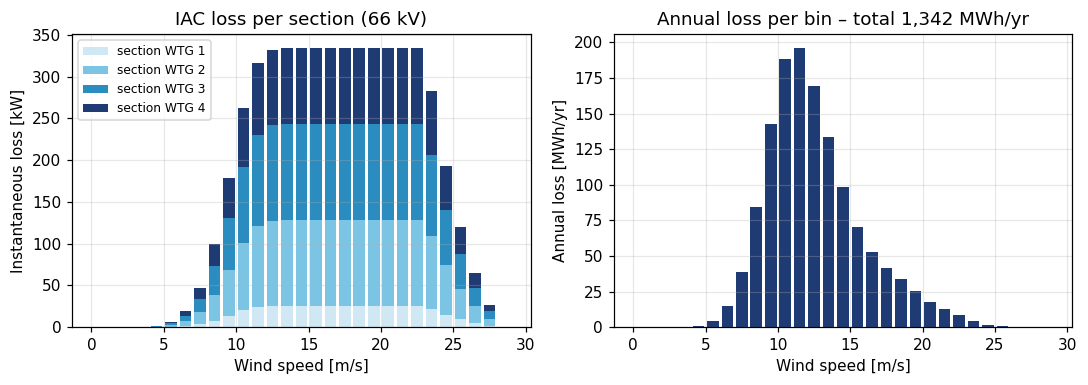

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(10, 3.6))
cols = [c for c in iac66.columns if c.startswith("P_loss WTG")]
bottom = np.zeros(len(iac66))
for c, colr in zip(cols, ["#cfe8f3", "#7cc4e4", "#2a8cbf", "#1f3b73"]):
    ax[0].bar(iac66["v [m/s]"], iac66[c], bottom=bottom, width=0.8, color=colr, label=c.replace("P_loss ", "section ").replace(" [kW]", ""))
    bottom += iac66[c].values
ax[0].set_xlabel("Wind speed [m/s]"); ax[0].set_ylabel("Instantaneous loss [kW]"); ax[0].legend(fontsize=8)
ax[0].set_title("IAC loss per section (66 kV)")
ax[1].bar(iac66["v [m/s]"], iac66["Loss [MWh/yr]"], width=0.8, color="#1f3b73")
ax[1].set_xlabel("Wind speed [m/s]"); ax[1].set_ylabel("Annual loss [MWh/yr]")
ax[1].set_title(f"Annual loss per bin – total {loss66:,.0f} MWh/yr")
fig.tight_layout(); fig.savefig(FIG / "p2_iac_losses.png"); plt.show()

## Q4 – Number of 20 MW WTGs on Cable 1 at 132 kV

In [9]:
I_WTG_132 = S_WTG * 1e3 / (np.sqrt(3) * 132)
n132 = int(np.floor(cables.loc["Cable 1", "ampacity_A"] / I_WTG_132))
print(f"I_WTG at 132 kV = {I_WTG_132:.1f} A -> 424 / {I_WTG_132:.1f} = {424/I_WTG_132:.2f} -> {n132} WTGs on Cable 1")
for c in cables.index:
    print(f"  {c}: {int(cables.loc[c,'ampacity_A']//I_WTG_132)} WTGs at 132 kV (vs {cables.loc[c,'n_max WTGs']} at 66 kV)")

I_WTG at 132 kV = 92.1 A -> 424 / 92.1 = 4.60 -> 4 WTGs on Cable 1
  Cable 1: 4 WTGs at 132 kV (vs 2 at 66 kV)
  Cable 2: 6 WTGs at 132 kV (vs 3 at 66 kV)
  Cable 3: 8 WTGs at 132 kV (vs 4 at 66 kV)


## Q5 – Annual loss reduction at 132 kV (everything else equal)
Same cables, same resistance, same power → current halves → $P_{loss} \propto I^2$ drops by a factor 4.

In [10]:
iac132 = string_losses(132, sections)
loss132 = iac132["Loss [MWh/yr]"].sum()
print(f"66 kV : {loss66:8.1f} MWh/yr ({100*loss66/yield_string:.3f} %)")
print(f"132 kV: {loss132:8.1f} MWh/yr ({100*loss132/yield_string:.3f} %)")
print(f"Reduction: {loss66-loss132:.1f} MWh/yr = {100*(1-loss132/loss66):.0f} %  (factor {loss66/loss132:.1f})")

# Variant (for discussion): at 132 kV the cheapest cable (Cable 1) is sufficient for all four sections
sec132 = sections.copy(); sec132["cable"] = 1; sec132["R [ohm/km]"] = 0.101
loss132_c1 = string_losses(132, sec132)["Loss [MWh/yr]"].sum()
print(f"\nVariant: 132 kV with Cable 1 in all sections -> {loss132_c1:.1f} MWh/yr "
      f"({100*(1-loss132_c1/loss66):.0f} % lower than 66 kV base case, {100*loss132_c1/yield_string:.3f} %)")

66 kV :   1341.6 MWh/yr (0.340 %)
132 kV:    335.4 MWh/yr (0.085 %)
Reduction: 1006.2 MWh/yr = 75 %  (factor 4.0)

Variant: 132 kV with Cable 1 in all sections -> 562.1 MWh/yr (58 % lower than 66 kV base case, 0.142 %)


In [11]:
summary = pd.DataFrame({
    "66 kV (base)": [I_WTG, cables.loc["Cable 1", "n_max WTGs"], loss66, 100*loss66/yield_string],
    "132 kV (same cables)": [I_WTG_132, n132, loss132, 100*loss132/yield_string],
    "132 kV (Cable 1 everywhere)": [I_WTG_132, n132, loss132_c1, 100*loss132_c1/yield_string]},
    index=["I per WTG [A]", "max WTGs on Cable 1", "IAC loss [MWh/yr]", "loss [% of yield]"])
summary.round(3)

,66 kV (base),132 kV (same cables),132 kV (Cable 1 everywhere)
I per WTG [A],184.163,92.081,92.081
max WTGs on Cable 1,2.000,4.000,4.000
IAC loss [MWh/yr],1341.619,335.405,562.106
loss [% of yield],0.340,0.085,0.142
